In [13]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=2NJ6tSQzAKHGDMEr0cCWLy1avaXORN&access_type=offline&code_challenge=Ll2zRAYORV7PWHVMeZGsxJj-maXyqb0t_Up7A76eEsc&code_challenge_method=S256



Command killed by keyboard interrupt

^C


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from open3d import geometry, utility, visualization

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
from typing import Optional
import warnings
# Disable annoying warnings from PyArrow using under the hood.
warnings.simplefilter(action='ignore', category=FutureWarning)

from src.dataset import WaymoLoader
from src.visualization import show_camera_image, show_point_cloud

from waymo_open_dataset import v2
import tensorflow as tf
import matplotlib.pyplot as plt

I0000 00:00:1785873152.365969  198351 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785873152.486983  198351 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785873158.013089  198351 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785873186.720087  198351 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [4]:
loader = WaymoLoader(
        dataset_dir="gs://waymo_open_dataset_v_2_0_1/training",
        context_name="10876852935525353526_1640_000_1660_000",
        cache_dir="/media/cheeko/6E92406092402EC1/Abhilash/github/waymo-lidar-transformer/data/raw",
        use_cache=True,
    )

In [6]:
frame_index = 130
camera_name = "side_left"
lidar_name = "top"

frame = loader.load_frame(frame_index, 
                          return_array=True, 
                          lidar_name=lidar_name,
                          camera_name=camera_name)

/media/cheeko/6E92406092402EC1/Abhilash/github/waymo-lidar-transformer/.venv/lib/python3.12/site-packages/dask/dataframe/core.py:383: UserWarning: Insufficient elements for `head`. 1 elements requested, only 0 elements available. Try passing larger `npartitions` to `head`.
  warnings.warn(


LookupError: No row found for component 'lidar' with filters {'key.segment_context_name': '10876852935525353526_1640_000_1660_000', 'key.laser_name': 1, 'key.frame_timestamp_micros': np.int64(1549638671587698)}.

In [5]:
lidar_df = loader.read_component("lidar")
lidar_df.info()

<class 'dask.dataframe.dask_expr.DataFrame'>
Columns: 7 entries, key.segment_context_name to [LiDARComponent].range_image_return2.shape
dtypes: string(1), object(4), int64(1), int8(1)

In [ ]:
lidar_df["key.laser_name"].value_counts().compute()

key.segment_context_name
10876852935525353526_1640_000_1660_000    995
Name: count, dtype: int64[pyarrow]

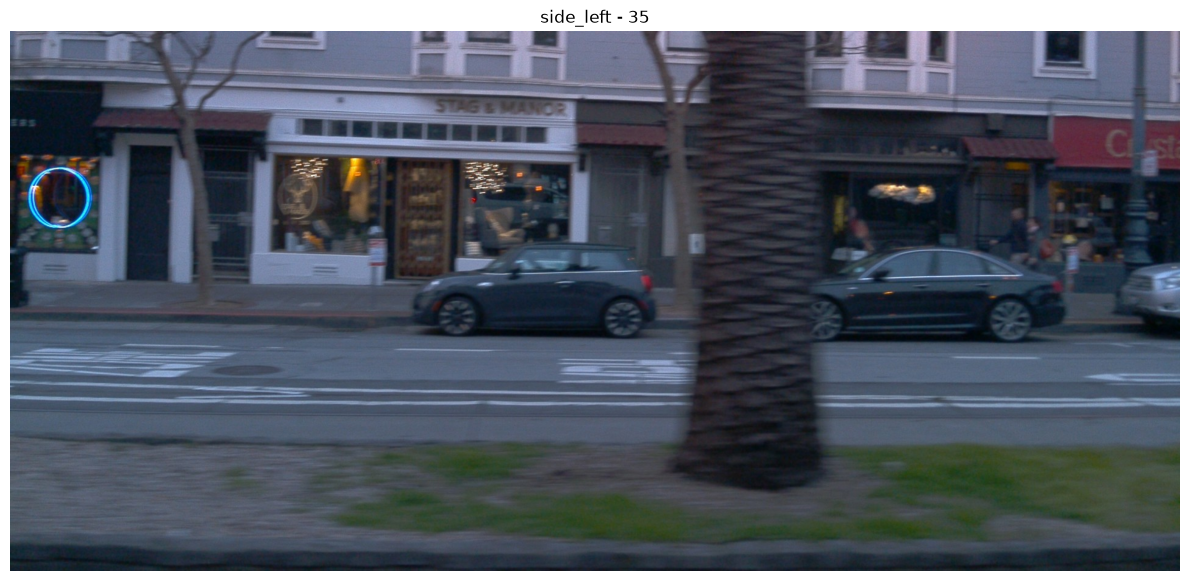

In [6]:
show_camera_image(frame["camera"], title=f"{camera_name} - {frame_index}")

In [11]:
top_points = loader.load_frame(frame_index=frame_index, return_array=True)["lidar"]
front_points = loader.load_frame(frame_index=frame_index, return_array=True, lidar_name="front")["lidar"]

top_points.shape, front_points.shape

pixel pose is  there
pixel pose is  not there
pixel pose is  not there
pixel pose is  not there


((161841, 3), (3776, 3))

In [13]:
top_points_raw = loader.load_frame(frame_index=frame_index, return_array=True, lidar_name="top", camera_name=None)["lidar"]

top_points_raw.shape

pixel pose is  not there
pixel pose is  not there


(161841, 3)

In [ ]:
top_points_cloud = geometry.PointCloud()
top_points_cloud.points = utility.Vector3dVector(top_points[:, :3])

top_points_raw_cloud = geometry.PointCloud()
top_points_raw_cloud.points = utility.Vector3dVector(top_points_raw[:, :3])
top_points_raw_cloud.paint_uniform_color([0.5, 0.5, 0.5])  # Set color to gray

visualization.draw_geometries([top_points_cloud, top_points_raw_cloud], window_name="Top LiDAR Point Cloud")

In [14]:
point_cloud = geometry.PointCloud()
point_cloud.points = utility.Vector3dVector(top_points_raw[:, :3])

visualization.draw_geometries([point_cloud], window_name="Top LiDAR Raw Point Cloud")

In [ ]:
del top_points, front_points, top_points_raw, top_points_cloud, top_points_raw_cloud, point_cloud

import gc; gc.collect()


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



792

In [ ]:
head_front_camera = head[head["key.camera_name"] == 1]

for i, (_, r) in enumerate(head_front_camera.iterrows()):
    # Create component dataclasses for the raw data
    cam_image = v2.CameraImageComponent.from_dict(r)
    cam_image_arr = tf.image.decode_jpeg(cam_image.image).numpy()
    plt.imshow(cam_image_arr)
    plt.title(f"Frame {cam_image.key.frame_timestamp_micros}, Camera: {cam_image.key.camera_name}")
    plt.show()

In [4]:
camera_image_ftm = camera_image_df["key.frame_timestamp_micros"].compute()

In [31]:
lidar_pose_df = loader.read_component("lidar_pose")

In [40]:
del lidar_pose_df

In [5]:
lidar_df = loader.read_component("lidar")
# lidar_head = lidar_df.head()

In [6]:
lidar_ftm = lidar_df["key.frame_timestamp_micros"].compute()

In [9]:
lidar_laser_names = lidar_df["key.laser_name"].compute()

In [11]:
lidar_laser_names.unique()

array([1, 2, 3, 4, 5], dtype=int8)

In [16]:
import gc
gc.collect()

4991